# EdgeRunner | EDA 02: auditoria del split temporal

**Pregunta:** un unico corte `train / validation / test` por dias es honesto frente a leakage, pero es suficiente para juzgar un predictor?

**Respuesta corta:** no como unico mecanismo de seleccion. Este cuaderno cuantifica deriva del target y contratos que atraviesan fronteras, y propone una validacion `purged expanding walk-forward` con un test terminal bloqueado.

Este sigue siendo trabajo exploratorio: no se entrena ningun modelo.

## Por que revisar la division inicial

El corte cronologico inicial tiene una virtud importante: no mezcla indiscriminadamente el futuro con el pasado. Sin embargo, puede producir una conclusion dependiente de un unico regimen si validacion o test contienen distinta proporcion de eventos accionables, liquidez o volatilidad.

Ademas, en mercados con ventanas `5m / 15m / 1h`, un mismo `condition_id` puede estar observado a ambos lados de una frontera diaria. Aunque eso no sea leakage de etiqueta directo, aumenta dependencia entre bloques, sobre todo si mas adelante entran metadata o contexto del contrato.

In [1]:
from pathlib import Path
import sqlite3
import time

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import HTML, Markdown, display

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

DB_PATH = Path(r'D:\polymarket_btc_probe_official_v1\polymarket_week.sqlite3')
con = sqlite3.connect(f"file:{DB_PATH.as_posix()}?mode=ro&immutable=1", uri=True)
con.execute('PRAGMA query_only = ON')
FILTER_SQL = """
s.dataset_tier = 'core'
AND t.coverage_ratio >= 0.97
AND t.quality_score >= 70
AND t.core_gap_severe_segment_count = 0
""".strip()
SPLIT_SQL = """
CASE
  WHEN substr(s.created_at_utc, 1, 10) <= '2026-05-20' THEN 'train'
  WHEN substr(s.created_at_utc, 1, 10) <= '2026-05-22' THEN 'validation'
  ELSE 'test'
END
""".strip()
QUERY_LOG = []

def query(name, sql):
    start = time.perf_counter()
    result = pd.read_sql_query(sql, con)
    QUERY_LOG.append({'consulta': name, 'segundos': time.perf_counter() - start})
    return result

def integer(x):
    return f'{int(x):,}'.replace(',', '.')

print('DB abierta en lectura:', DB_PATH)
print('query_only:', con.execute('PRAGMA query_only').fetchone()[0])

DB abierta en lectura: D:\polymarket_btc_probe_official_v1\polymarket_week.sqlite3
query_only: 1


## 1. Diagnostico del corte inicial

El corte inicial se reinterpreta aqui como **holdout terminal candidato**:

- train: `2026-05-11` a `2026-05-20`
- validation: `2026-05-21` a `2026-05-22`
- test: `2026-05-23` a `2026-05-25`

Un test futuro con distribucion distinta no es necesariamente un defecto: puede ser precisamente la prueba de robustez que interesa. El problema aparece si una sola validacion decide todo el modelado.

split,sessions,avg_quality,startup_seconds,ready_ratio,first_day,last_day,label_rows,label_pct
train,"1,765",99.772,9.992,1.000000,2026-05-11,2026-05-20,"1,649,024",68.14%
validation,345,99.904,9.129,1.000000,2026-05-21,2026-05-22,"322,434",13.32%
test,480,99.908,8.939,1.000000,2026-05-23,2026-05-25,"448,562",18.54%


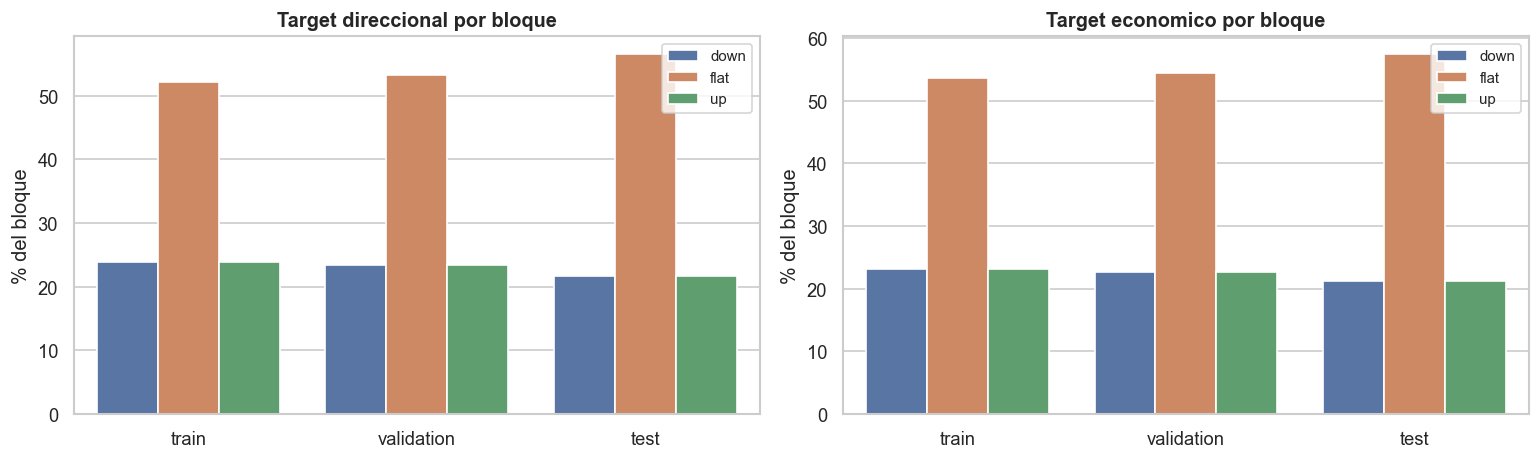

In [2]:
block_quality = query('calidad por bloque', f"""
SELECT
  {SPLIT_SQL} AS split,
  COUNT(*) AS sessions,
  AVG(t.quality_score) AS avg_quality,
  AVG(t.startup_latency_seconds) AS startup_seconds,
  AVG(t.predictor_core_ready_ratio) AS ready_ratio,
  MIN(substr(s.created_at_utc, 1, 10)) AS first_day,
  MAX(substr(s.created_at_utc, 1, 10)) AS last_day
FROM collection_sessions s
JOIN collection_session_telemetry t ON t.session_id = s.id
WHERE {FILTER_SQL}
GROUP BY split
""")
block_targets = query('targets por bloque', f"""
SELECT
  {SPLIT_SQL} AS split,
  l.label_name,
  l.economic_label_name,
  COUNT(*) AS rows
FROM predictor_labels AS l INDEXED BY idx_predictor_labels_label
JOIN collection_sessions s ON s.id = l.session_id
JOIN collection_session_telemetry t ON t.session_id = s.id
WHERE {FILTER_SQL}
GROUP BY split, l.label_name, l.economic_label_name
""")
labels_by_split = block_targets.groupby(['split', 'label_name'], as_index=False)['rows'].sum()
labels_by_split['pct'] = 100 * labels_by_split['rows'] / labels_by_split.groupby('split')['rows'].transform('sum')
economic_by_split = block_targets.groupby(['split', 'economic_label_name'], as_index=False)['rows'].sum()
economic_by_split['pct'] = 100 * economic_by_split['rows'] / economic_by_split.groupby('split')['rows'].transform('sum')
split_total = labels_by_split.groupby('split', as_index=False)['rows'].sum().rename(columns={'rows': 'label_rows'})
block_summary = block_quality.merge(split_total, on='split')
block_summary['label_pct'] = 100 * block_summary['label_rows'] / block_summary['label_rows'].sum()
order = pd.CategoricalDtype(['train', 'validation', 'test'], ordered=True)
for frame in [block_summary, labels_by_split, economic_by_split]:
    frame['split'] = frame['split'].astype(order)
block_summary = block_summary.sort_values('split')

display(block_summary.style.format({
    'sessions': '{:,.0f}', 'avg_quality': '{:.3f}', 'startup_seconds': '{:.3f}',
    'ready_ratio': '{:.6f}', 'label_rows': '{:,.0f}', 'label_pct': '{:.2f}%'
}).hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=labels_by_split, x='split', y='pct', hue='label_name', hue_order=['down', 'flat', 'up'], ax=axes[0])
axes[0].set(title='Target direccional por bloque', xlabel='', ylabel='% del bloque')
sns.barplot(data=economic_by_split, x='split', y='pct', hue='economic_label_name', hue_order=['down', 'flat', 'up'], ax=axes[1])
axes[1].set(title='Target economico por bloque', xlabel='', ylabel='% del bloque')
for ax in axes:
    ax.legend(title='', fontsize=9)
plt.tight_layout()
plt.show()

In [3]:
flat_directional = labels_by_split[labels_by_split['label_name'] == 'flat'].set_index('split')['pct']
flat_economic = economic_by_split[economic_by_split['economic_label_name'] == 'flat'].set_index('split')['pct']
display(Markdown(
    f"**Deriva visible.** `flat` direccional pasa de `{flat_directional.loc['train']:.2f}%` "
    f"en train a `{flat_directional.loc['test']:.2f}%` en test, una diferencia de "
    f"`{flat_directional.loc['test'] - flat_directional.loc['train']:.2f}` puntos. "
    f"En el target economico la diferencia es de "
    f"`{flat_economic.loc['test'] - flat_economic.loc['train']:.2f}` puntos. "
    "Esto justifica evaluar estabilidad en varias ventanas anteriores y conservar el "
    "bloque final como prueba realmente no vista."
))

**Deriva visible.** `flat` direccional pasa de `52.19%` en train a `56.53%` en test, una diferencia de `4.34` puntos. En el target economico la diferencia es de `3.85` puntos. Esto justifica evaluar estabilidad en varias ventanas anteriores y conservar el bloque final como prueba realmente no vista.

## 2. Deriva diaria del target

Si el balance de clases fluctua por dia, una unica ventana de validacion puede premiar por azar una regla ajustada a ese tramo. Esta grafica no selecciona datos: muestra el reto que debera soportar cualquier baseline.

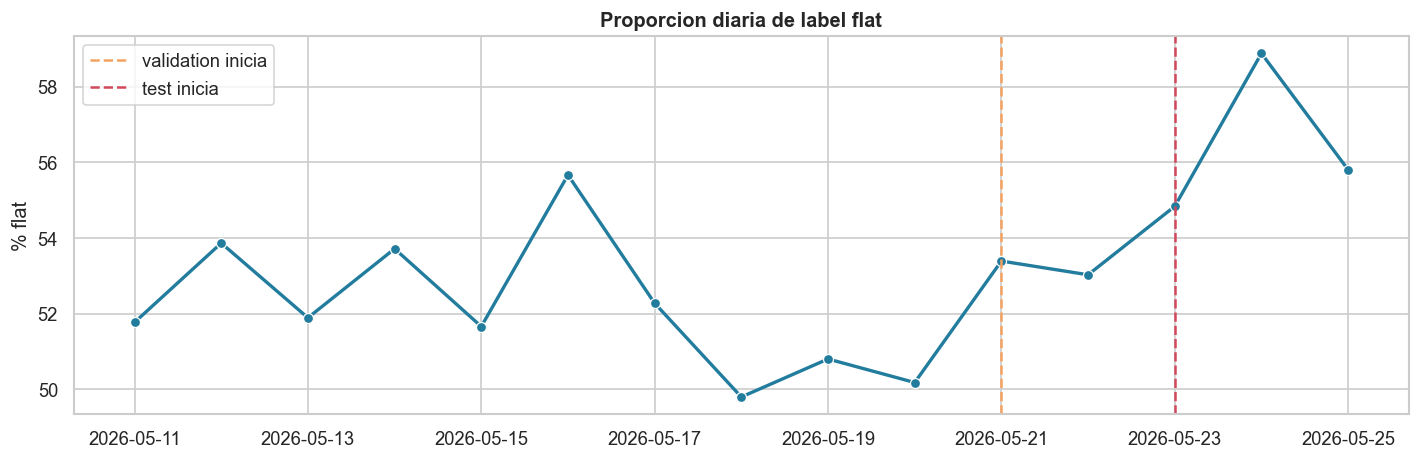

day,rows,pct
2026-05-11,"50,247",51.77%
2026-05-12,"102,112",53.87%
2026-05-13,"98,271",51.89%
2026-05-14,"63,646",53.72%
2026-05-15,"95,609",51.66%
2026-05-16,"104,153",55.66%
2026-05-17,"93,345",52.28%
2026-05-18,"86,591",49.80%
2026-05-19,"84,521",50.80%
2026-05-20,"82,068",50.18%


In [4]:
daily_targets = query('labels diarios', f"""
SELECT
  substr(s.created_at_utc, 1, 10) AS day,
  l.label_name,
  COUNT(*) AS rows
FROM predictor_labels AS l INDEXED BY idx_predictor_labels_label
JOIN collection_sessions s ON s.id = l.session_id
JOIN collection_session_telemetry t ON t.session_id = s.id
WHERE {FILTER_SQL}
GROUP BY day, l.label_name
ORDER BY day, l.label_name
""")
daily_targets['pct'] = 100 * daily_targets['rows'] / daily_targets.groupby('day')['rows'].transform('sum')
daily_flat = daily_targets[daily_targets['label_name'] == 'flat'].copy()
daily_flat['day'] = pd.to_datetime(daily_flat['day'])

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=daily_flat, x='day', y='pct', marker='o', linewidth=2, color='#227c9d', ax=ax)
ax.axvline(pd.Timestamp('2026-05-21'), color='#f4a261', linestyle='--', label='validation inicia')
ax.axvline(pd.Timestamp('2026-05-23'), color='#d1495b', linestyle='--', label='test inicia')
ax.set(title='Proporcion diaria de label flat', xlabel='', ylabel='% flat')
ax.legend()
plt.tight_layout()
plt.show()
display(daily_flat.assign(day=daily_flat['day'].dt.strftime('%Y-%m-%d'))[['day', 'rows', 'pct']].style.format({'rows': '{:,.0f}', 'pct': '{:.2f}%'}).hide(axis='index'))

## 3. Dependencia de contratos en las fronteras

Se audita `condition_id` desde `session_market_tradability`, que ya contiene la identidad del mercado y evita leer JSON crudo de metadata. Si una condicion aparece a ambos lados de una frontera, la recomendacion conservadora es purgarla del conjunto de ajuste antes de evaluar el bloque siguiente.

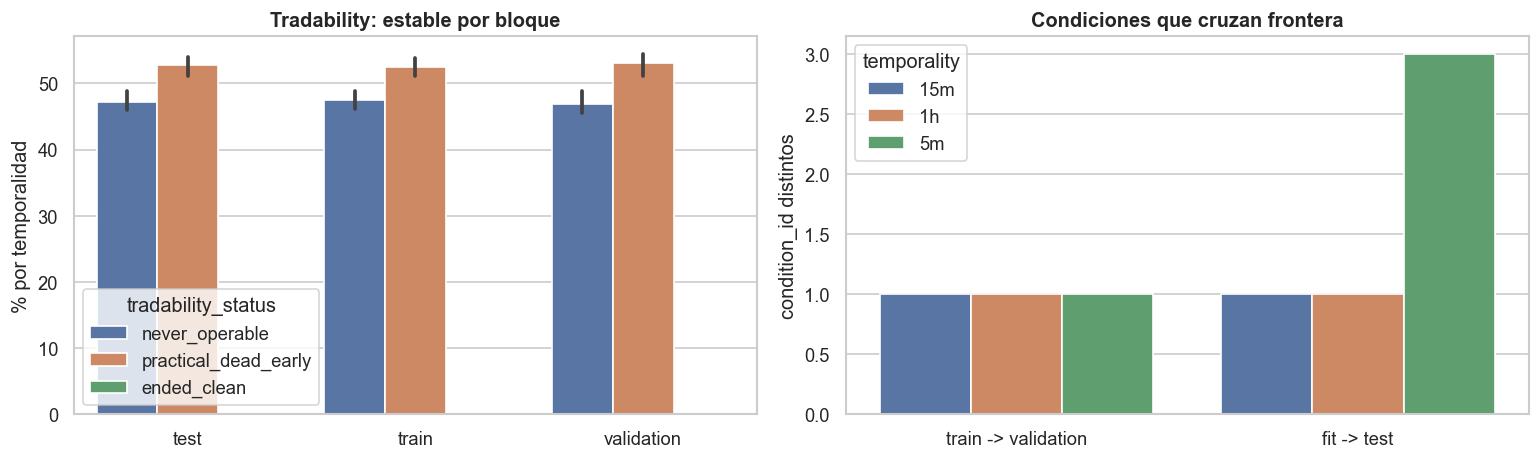

temporality,conditions_crossing,boundary
15m,1,train -> validation
1h,1,train -> validation
5m,1,train -> validation
15m,1,fit -> test
1h,1,fit -> test
5m,3,fit -> test


In [5]:
tradability_blocks = query('tradability por bloque', f"""
SELECT
  {SPLIT_SQL} AS split,
  mt.temporality,
  mt.tradability_status,
  COUNT(*) AS session_markets,
  100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY {SPLIT_SQL}, mt.temporality) AS pct_within_temporality,
  AVG(mt.full_book_ratio) AS full_book_ratio,
  AVG(mt.degraded_ratio) AS degraded_ratio
FROM session_market_tradability mt
JOIN collection_sessions s ON s.id = mt.session_id
JOIN collection_session_telemetry t ON t.session_id = s.id
WHERE {FILTER_SQL}
GROUP BY split, mt.temporality, mt.tradability_status
""")
boundaries = [
    ('train -> validation', '2026-05-20', '2026-05-21', '2026-05-22'),
    ('fit -> test', '2026-05-22', '2026-05-23', '2026-05-25'),
]
overlap_frames = []
for boundary, fit_end, eval_start, eval_end in boundaries:
    overlap = query(f'overlap {boundary}', f"""
    WITH tagged AS (
      SELECT DISTINCT
        mt.condition_id,
        mt.temporality,
        CASE
          WHEN substr(s.created_at_utc, 1, 10) <= '{fit_end}' THEN 'fit'
          WHEN substr(s.created_at_utc, 1, 10) BETWEEN '{eval_start}' AND '{eval_end}' THEN 'eval'
        END AS part
      FROM session_market_tradability mt
      JOIN collection_sessions s ON s.id = mt.session_id
      JOIN collection_session_telemetry t ON t.session_id = s.id
      WHERE {FILTER_SQL}
        AND (substr(s.created_at_utc, 1, 10) <= '{fit_end}'
             OR substr(s.created_at_utc, 1, 10) BETWEEN '{eval_start}' AND '{eval_end}')
    ), overlapping AS (
      SELECT condition_id, temporality
      FROM tagged
      WHERE part IS NOT NULL
      GROUP BY condition_id, temporality
      HAVING COUNT(DISTINCT part) > 1
    )
    SELECT temporality, COUNT(*) AS conditions_crossing
    FROM overlapping
    GROUP BY temporality
    ORDER BY temporality
    """)
    overlap['boundary'] = boundary
    overlap_frames.append(overlap)
overlaps = pd.concat(overlap_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=tradability_blocks, x='split', y='pct_within_temporality', hue='tradability_status', ax=axes[0])
axes[0].set(title='Tradability: estable por bloque', xlabel='', ylabel='% por temporalidad')
sns.barplot(data=overlaps, x='boundary', y='conditions_crossing', hue='temporality', ax=axes[1])
axes[1].set(title='Condiciones que cruzan frontera', xlabel='', ylabel='condition_id distintos')
plt.tight_layout()
plt.show()
display(overlaps.style.format({'conditions_crossing': '{:,.0f}'}).hide(axis='index'))

In [6]:
crossing_fit_validation = int(overlaps.loc[overlaps['boundary'] == 'train -> validation', 'conditions_crossing'].sum())
crossing_test = int(overlaps.loc[overlaps['boundary'] == 'fit -> test', 'conditions_crossing'].sum())
display(Markdown(
    f"**Dependencia de identidad.** Cruzan la frontera train-validation "
    f"`{crossing_fit_validation}` condiciones y la frontera hacia el test terminal "
    f"`{crossing_test}` condiciones. Son pocas, asi que purgarlas del ajuste tiene "
    "un coste pequeno y mejora la interpretabilidad de la evaluacion."
))

**Dependencia de identidad.** Cruzan la frontera train-validation `3` condiciones y la frontera hacia el test terminal `5` condiciones. Son pocas, asi que purgarlas del ajuste tiene un coste pequeno y mejora la interpretabilidad de la evaluacion.

## 4. Estrategias consideradas

| Estrategia | Ventaja | Riesgo | Decision |
|---|---|---|---|
| Split aleatorio por filas | Facil y balanceado | Leakage severo por autocorrelacion y contratos repetidos | Rechazado |
| Un unico split cronologico | Simula un unico despliegue futuro | Seleccion fragil ante regimen de validacion particular | Util solo como test terminal |
| Split temporal estratificado artificialmente | Puede igualar balances | Deja de representar el futuro observado y filtra informacion del test | Rechazado como metrica principal |
| Walk-forward expanding purgado | Mide estabilidad en varios futuros, conserva causalidad | Mas coste experimental | Recomendado para desarrollo |
| Rolling window purgado | Responde mejor a drift fuerte | Descarta historia y anade otra eleccion de ventana | Experimento posterior |

**Purgado propuesto:** retirar del conjunto de ajuste cualquier `condition_id` que aparezca en el bloque evaluado. Al construir secuencias, aplicar ademas un embargo alrededor de cada frontera de al menos `max(8 s, longitud_de_ventana_historica)`; ocho segundos son el horizonte actual del label, pero el lookback del modelo podria exigir mas.

## 5. Plan recomendado: expanding walk-forward + test bloqueado

La propuesta no mira el test para afinar modelos. El periodo final queda sellado y solo se abre cuando se haya elegido una familia de baseline y sus decisiones con los folds anteriores.

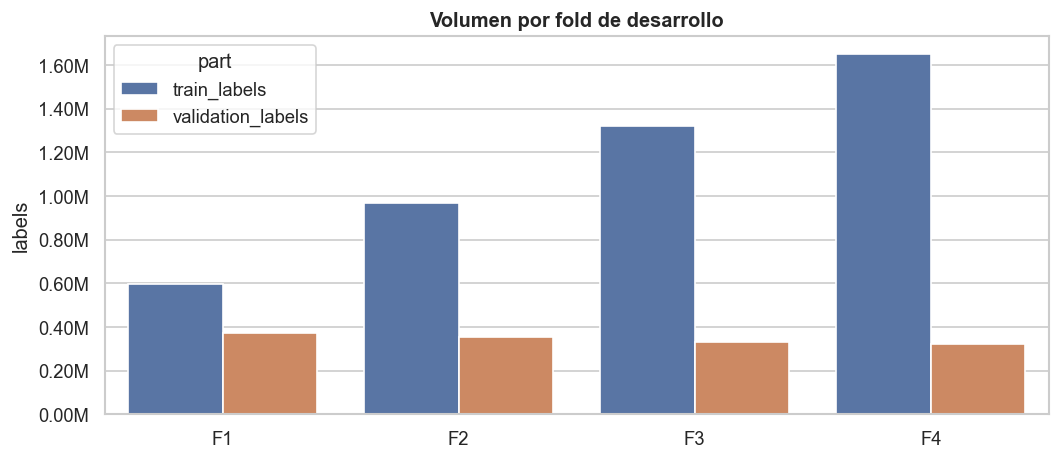

fold,train_days,validation_days,train_sessions,train_labels,validation_sessions,validation_labels,conditions_to_purge
F1,2026-05-11 a 2026-05-14,2026-05-15 a 2026-05-16,637,"594,490",398,"372,178",5
F2,2026-05-11 a 2026-05-16,2026-05-17 a 2026-05-18,"1,035","966,668",377,"352,442",2
F3,2026-05-11 a 2026-05-18,2026-05-19 a 2026-05-20,"1,412","1,319,110",353,"329,914",7
F4,2026-05-11 a 2026-05-20,2026-05-21 a 2026-05-22,"1,765","1,649,024",345,"322,434",3


**Test terminal sellado:** `2026-05-23` a `2026-05-25`, `480` sesiones y `448,562` labels. No se usa para seleccionar features, modelo o umbrales.

In [7]:
daily_counts = query('conteos diarios labels y sesiones', f"""
SELECT
  substr(s.created_at_utc, 1, 10) AS day,
  COUNT(DISTINCT s.id) AS sessions,
  COUNT(l.session_id) AS labels
FROM collection_sessions s
JOIN collection_session_telemetry t ON t.session_id = s.id
LEFT JOIN predictor_labels AS l INDEXED BY sqlite_autoindex_predictor_labels_1
  ON l.session_id = s.id
WHERE {FILTER_SQL}
GROUP BY day
ORDER BY day
""")
daily_counts['day'] = pd.to_datetime(daily_counts['day'])
fold_specs = [
    ('F1', '2026-05-14', '2026-05-15', '2026-05-16'),
    ('F2', '2026-05-16', '2026-05-17', '2026-05-18'),
    ('F3', '2026-05-18', '2026-05-19', '2026-05-20'),
    ('F4', '2026-05-20', '2026-05-21', '2026-05-22'),
]
fold_rows = []
for fold, train_end, validation_start, validation_end in fold_specs:
    train = daily_counts[daily_counts['day'] <= train_end]
    validation = daily_counts[daily_counts['day'].between(validation_start, validation_end)]
    crossing = query(f'purga {fold}', f"""
    WITH tagged AS (
      SELECT DISTINCT mt.condition_id,
        CASE
          WHEN substr(s.created_at_utc, 1, 10) <= '{train_end}' THEN 'fit'
          WHEN substr(s.created_at_utc, 1, 10) BETWEEN '{validation_start}' AND '{validation_end}' THEN 'eval'
        END AS part
      FROM session_market_tradability mt
      JOIN collection_sessions s ON s.id = mt.session_id
      JOIN collection_session_telemetry t ON t.session_id = s.id
      WHERE {FILTER_SQL}
        AND substr(s.created_at_utc, 1, 10) <= '{validation_end}'
    )
    SELECT COUNT(*) AS crossing_conditions
    FROM (
      SELECT condition_id FROM tagged WHERE part IS NOT NULL
      GROUP BY condition_id HAVING COUNT(DISTINCT part) > 1
    )
    """).iloc[0, 0]
    fold_rows.append({
        'fold': fold,
        'train_days': f'2026-05-11 a {train_end}',
        'validation_days': f'{validation_start} a {validation_end}',
        'train_sessions': train['sessions'].sum(),
        'train_labels': train['labels'].sum(),
        'validation_sessions': validation['sessions'].sum(),
        'validation_labels': validation['labels'].sum(),
        'conditions_to_purge': crossing,
    })
fold_plan = pd.DataFrame(fold_rows)
terminal = daily_counts[daily_counts['day'].between('2026-05-23', '2026-05-25')]

fig, ax = plt.subplots(figsize=(9, 4))
plot = fold_plan.melt(id_vars='fold', value_vars=['train_labels', 'validation_labels'], var_name='part', value_name='labels')
sns.barplot(data=plot, x='fold', y='labels', hue='part', ax=ax)
ax.set(title='Volumen por fold de desarrollo', xlabel='', ylabel='labels')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
plt.tight_layout()
plt.show()
display(fold_plan.style.format({
    'train_sessions': '{:,.0f}', 'train_labels': '{:,.0f}',
    'validation_sessions': '{:,.0f}', 'validation_labels': '{:,.0f}',
    'conditions_to_purge': '{:,.0f}'
}).hide(axis='index'))
display(Markdown(
    f"**Test terminal sellado:** `2026-05-23` a `2026-05-25`, "
    f"`{int(terminal['sessions'].sum()):,}` sesiones y `{int(terminal['labels'].sum()):,}` labels. "
    "No se usa para seleccionar features, modelo o umbrales."
))

## 6. Decision revisada

1. Mantener el test terminal `2026-05-23` a `2026-05-25` como evaluacion final una sola vez.
2. Reemplazar la unica validation por cuatro folds `expanding walk-forward` dentro de `2026-05-11` a `2026-05-22`.
3. Purgar del ajuste los `condition_id` presentes en cada bloque evaluado y usar embargo temporal al definir secuencias.
4. Reportar resultados por temporalidad y por balance de target; no esconder que el tramo final tiene mas clase `flat`.
5. Dejar `rolling window` como prueba de robustez si los folds muestran degradacion por drift, no como primer protocolo.

Esta estrategia conserva el realismo temporal y reduce la dependencia de una unica eleccion de fechas, sin introducir el leakage de un split aleatorio.

In [8]:
timings = pd.DataFrame(QUERY_LOG).sort_values('segundos', ascending=False)
display(Markdown('### Coste de consultas'))
display(timings.style.format({'segundos': '{:.3f}'}).hide(axis='index'))
con.close()

### Coste de consultas

consulta,segundos
targets por bloque,2.303
labels diarios,1.978
conteos diarios labels y sesiones,1.284
overlap fit -> test,0.038
tradability por bloque,0.031
purga F4,0.023
overlap train -> validation,0.023
calidad por bloque,0.020
purga F3,0.019
purga F2,0.016
